# Data Generator Notebook

This notebook generates (non-)Gaussian fields using CAMB and saves them in a .npy file and as tensorboard datasets.

Base code was taken from Thomas

Modifications by Brandon

In [100]:
%load_ext autoreload
%autoreload 2

import os
import re
from functools import partial
from logging import CRITICAL, DEBUG, ERROR, FATAL, INFO, WARNING

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

from CMBMap import CMBMap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Functions

In [102]:
def _save(dir, filename, maps):
    if not os.path.exists(dir):
        os.makedirs(dir)
    print(f"Saving to {dir}/{filename}...", end=" ")
    with open(f"{dir}/{filename}", "xb") as f:
        np.save(f, maps)
    print("Done!")


def _make_map(box_size, grid, cosmo, transfers, log_level, k_cut_low, k_cut_high, fnl, seed=None):  # box_size, grid, k_cut_low=None,k_cut_high=None):
    base_field = CMBMap(
        box_size,
        grid,
        cosmo=cosmo,
        run_camb=False,
        transfers=transfers,
        log_level=log_level,
    )
    if seed is None: seed = np.random.randint(0, 2**32-1)
    
    base_field.GenerateField(f_nl=fnl, seed=seed, k_cut_low=k_cut_low, k_cut_high=k_cut_high)
    return base_field.get_map()

def run_simulations(
    data_dir,
    name,
    num_sim,
    save_steps,
    num_dup_backgrounds,
    box_size,
    grid,
    fnls,
    force_fnl=None,
    n_jobs=-1,
    k_cut_low=None,
    k_cut_high=None,
    log_level=WARNING,
    cosmo=None,
    verbose=False,
):
    print("Generating base field and transfers...")
    base = CMBMap(box_size, grid, cosmo=cosmo, log_level=log_level)
    transfers = base.calc_transfers()
    make_map = partial(_make_map, box_size, grid, cosmo, transfers, log_level, k_cut_low, k_cut_high)
    print("Done!")

    for i in range(0, num_sim//num_dup_backgrounds, save_steps):
        end_index = np.min([num_sim, i + save_steps])  # Prevents issues with file naming when num_sim % save_steps != 0
        seed = np.random.randint(0, 2**32-1)
        
        if verbose: print(f"Generating maps {i} to {end_index} out of {num_sim} for {name}...")
        for _ in range(num_dup_backgrounds):
            maps_chunk = Parallel(n_jobs=n_jobs, verbose=1)(
                [
                    delayed(make_map)(fnl if force_fnl is None else force_fnl, seed=seed)
                    for fnl in fnls[i:end_index]
                ]
            )
        if verbose: print("Done!")
        _save(data_dir, f"{name}_{i}-{end_index}.npy", maps_chunk)

def _bispectrum(box_size, grid, cosmo, transfers, log_level, fnl, seed=None):
    base_field = CMBMap(
        box_size,
        grid,
        cosmo=cosmo,
        run_camb=False,
        transfers=transfers,
        log_level=log_level,
    )
    if seed is None: seed = np.random.randint(0, 2**32-1)
    base_field.GenerateField(
        f_nl=fnl,
        seed = seed
    )
    return base_field.Bk(2.5, 3, 13, "All")

def get_bispectrum(fnl, num_bispectra, box_size, grid, log_level=WARNING, cosmo=None):
    print("Generating base field for bispectrum...")
    base = CMBMap(box_size, grid, cosmo=cosmo, log_level=log_level)
    transfers = base.calc_transfers()
    print("Done!")

    bispec = partial(_bispectrum, box_size, grid, cosmo, transfers, log_level)
    return np.array(
        Parallel(n_jobs=-1, verbose=1)(
            [delayed(bispec)(fnl, seed) for seed in range(num_bispectra)]
        )
    )

## Test Generation

### Test Settings

In [104]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 2500,
    'accuracy_boost': 4,
    'tcmb': 2.7255,
}

num_bispectra = 10**4
fnl_range=(-1000, 1000)
num_threads = -1 #for all cores
BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 128                          # Size of the grid

# needed values
kF = 2*np.pi / BoxSize              # Fundamental mode of the box
kNyq = kF * grid / 2                # Nyquist frequency of the grid

# Should we only generate the data, skipping tests and fisher forcasts?
run_test = True

[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
[ CMBMap -        calculate_cls() ] | INFO : PSMap shape: (128, 65), min: 0.0, max: 813.9020150440343, mean: 2.4339438336616546, rms: 18.123438733591136


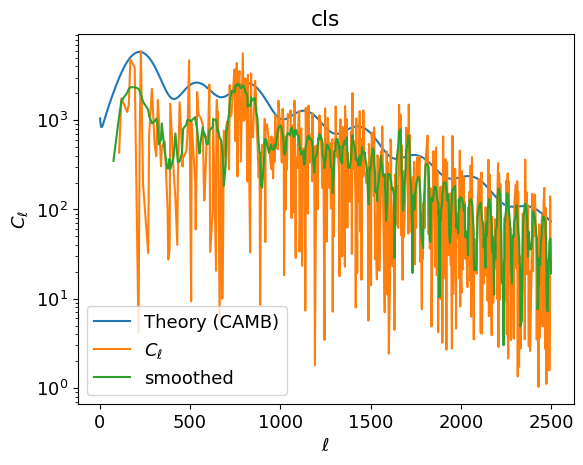

[ CMBMap -             plot_cmb() ] | INFO : map mean: 0.0, map rms: 0.012234242328343765


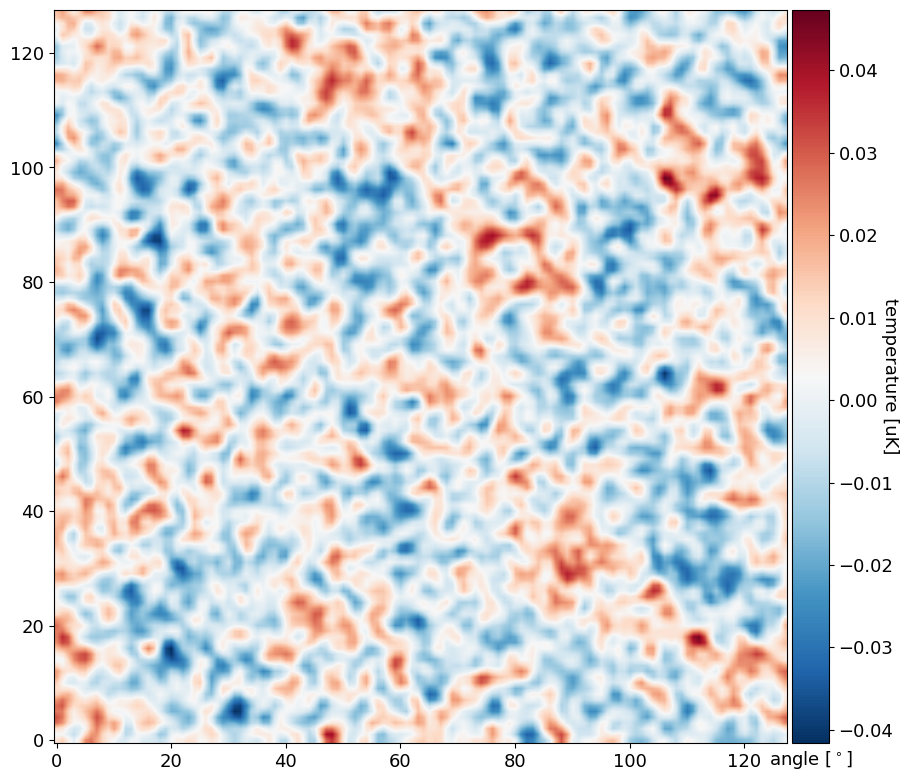

In [106]:
if run_test:
    test_map = CMBMap(BoxSize, grid, cosmo=cosmo_params, log_level=INFO)
    test_map.GenerateField(f_nl=1.,seed=0)
    
    test_map.plot_cls(title='cls')
    test_map.plot_cmb()

Now we test camb with a non-linear power spectrum

[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
[ CMBMap -             plot_cmb() ] | INFO : map mean: -2.710505431213761e-20, map rms: 0.012187415569399831


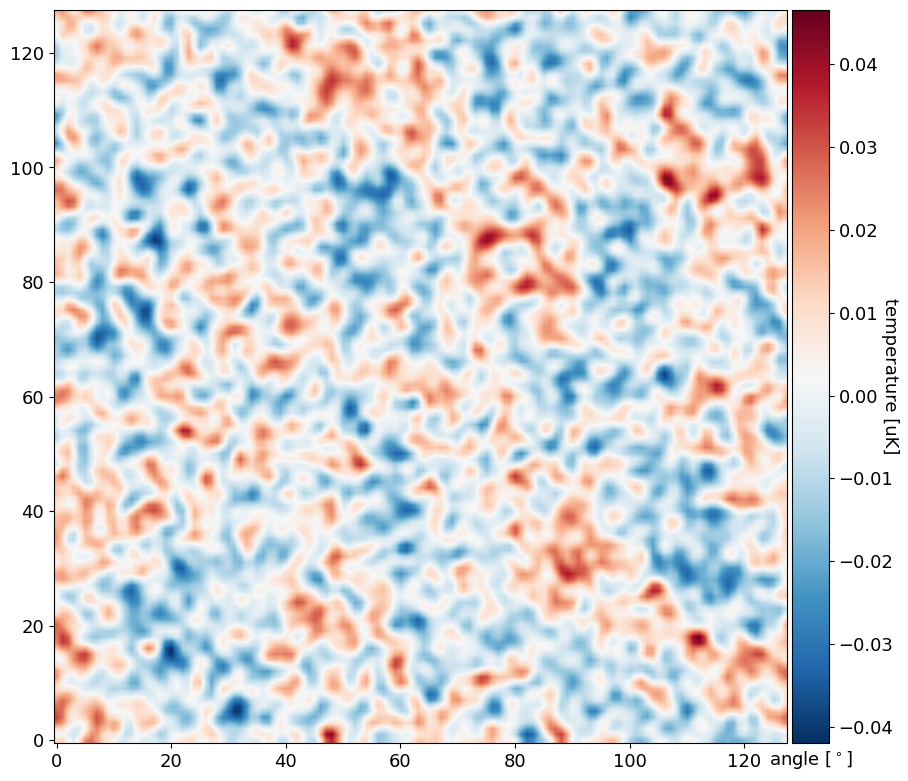

In [108]:
if run_test:
    FFT_map = CMBMap(BoxSize,grid,cosmo=cosmo_params)
    
    # Generate the same field but cut off at grid/3*kF (where FFT bispectrum measurements start to fail)
    FFT_map.GenerateField(f_nl=1.,k_cut_high=grid/3*kF)
    FFT_map.plot_cmb()

## Fisher Forecast

Computing Bispectra can be done as follows

kmax = 0.25132741228718347 0.268082573106329


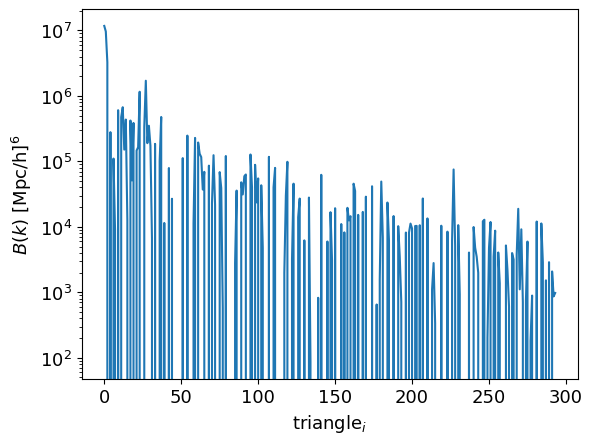

In [109]:
if run_test:
    # Compute the bispectrum in a given binning:
    BBB = FFT_map.Bk(2.5,3,13,'All')

    plt.semilogy(BBB[:,-2])
    plt.ylabel("$B(k)$ [Mpc/h]$^6$")
    plt.xlabel("triangle$_i$")
    print("kmax =",(BBB[-1,0]+1.5)*kF,grid/3*kF)

### Perform a Fisher forecast

We compute many bispectra with fixed amounts of pnG

In [110]:
if run_test:
    BispecP = get_bispectrum( 100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecM = get_bispectrum(-100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecG = get_bispectrum(   0, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)

Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 378 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 839 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 2624 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 4824 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done 7424 tasks      | elapsed:   26.1s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   28.7s finished


Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1008 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 2408 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 4208 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 6408 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 9008 tasks      | elapsed:    9.1s


Generating base field for bispectrum...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   10.1s finished


Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1080 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 2480 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 4280 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 6480 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 9080 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   10.4s finished


We compute the covariance matrix and its inverse, corrected by the Hartlap factor

[[ 8.33967380e+14  1.07007497e+13  8.62372359e+10 ... -3.28341639e+08
  -2.84302429e+08  7.17597952e+08]
 [ 1.07007497e+13  3.13772803e+14  1.05933888e+12 ...  2.49381327e+08
   2.92973942e+08  2.52657756e+08]
 [ 8.62372359e+10  1.05933888e+12  2.66957863e+13 ...  5.71957825e+07
   1.01931544e+08 -2.05260106e+07]
 ...
 [-3.28341639e+08  2.49381327e+08  5.71957825e+07 ...  3.00386659e+06
  -1.18171255e+04  4.17842035e+04]
 [-2.84302429e+08  2.92973942e+08  1.01931544e+08 ... -1.18171255e+04
   1.50781711e+06 -6.83717098e+02]
 [ 7.17597952e+08  2.52657756e+08 -2.05260106e+07 ...  4.17842035e+04
  -6.83717098e+02  2.76302245e+06]]
0.9704970497049705


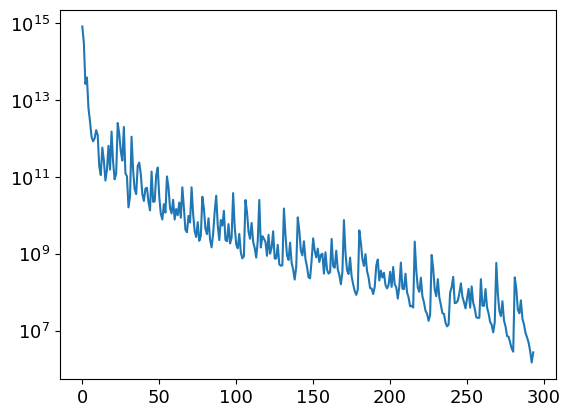

In [111]:
if run_test:
    Cov = np.cov(BispecG[:,:,-2].T)

    hartlapfactor = (len(BispecG) - len(Cov) - 2) / (len(BispecG) - 1)
    print(Cov)
    Cov_Inv = np.linalg.inv(Cov)
    Cov_Inv *= hartlapfactor

    Cov = np.diag(np.diag(Cov))
    plt.semilogy(np.diag(Cov))
    print(hartlapfactor)

We compute the derivative of the bispectra with respect to $f_{\rm NL}$

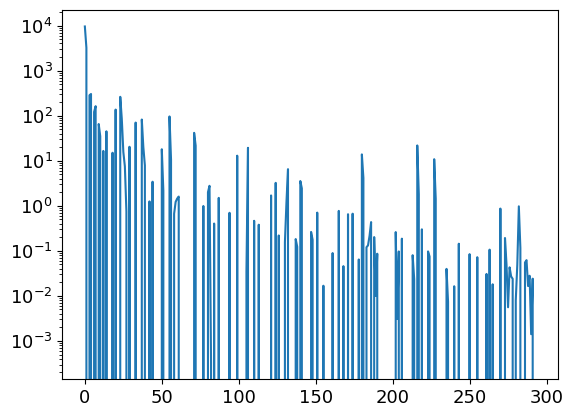

In [112]:
if run_test:
    dBdf = (BispecP.mean(0)[:,-2]-BispecM.mean(0)[:,-2])/200
    plt.semilogy(dBdf)
    plt.show()

### Then the Fisher information is given by $$F = \sum_{TT'} \frac{\partial B_T}{f_{\rm NL}} C^{-1}_{TT'} \frac{\partial B_{T'}}{f_{\rm NL}}$$ and the measurement error is $\sigma_{f_{\rm NL}} = F^{-1/2}$

In [113]:
if run_test:
    FF = (dBdf.dot(Cov_Inv).dot(dBdf))
    sigma = FF**-.5
    print(sigma)

758.0410976363985


### One can also estimate $f_{\rm NL}$ from the generated bispectra: $$\hat{f}_{\rm NL} = F^{-1}\sum{TT'}\frac{\partial B_T}{f_{\rm NL}}C^{-1}_{TT'} B_{T'}$$ where $B_{T'}$ is a measured bispectrum

In [114]:
if run_test:
    estimates_P = np.array([dBdf.dot(Cov_Inv).dot(BispecP[i,:,-2])/FF for i in tqdm(range(len(BispecP)))])
    estimates_M = np.array([dBdf.dot(Cov_Inv).dot(BispecM[i,:,-2])/FF for i in tqdm(range(len(BispecM)))])
    estimates_G = np.array([dBdf.dot(Cov_Inv).dot(BispecG[i,:,-2])/FF for i in tqdm(range(len(BispecG)))])

100%|██████████| 10000/10000 [00:00<00:00, 26274.90it/s]


In [115]:
if run_test: 
    print(estimates_P.mean(), estimates_M.mean(), estimates_G.mean())

105.3519694213863 -94.64803057861363 5.314283713554753


In [116]:
if run_test:
    print(estimates_P.std(), estimates_M.std(), estimates_G.std())

748.6445949473028 750.0876331184305 746.7378168118341


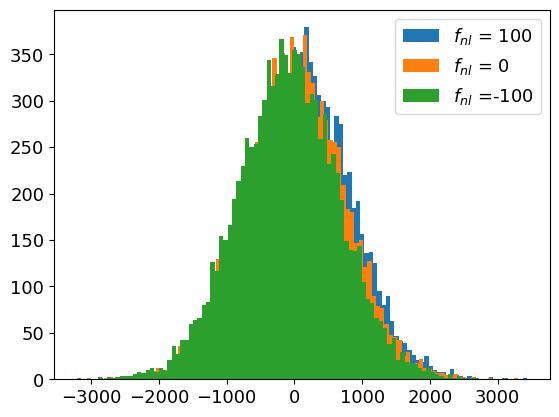

In [117]:
if run_test:
    plt.hist(estimates_P,bins=100, label=r"$f_{nl}$ = 100")
    plt.hist(estimates_G,bins=100, label=r"$f_{nl}$ = 0")
    plt.hist(estimates_M,bins=100, label=r"$f_{nl}$ =-100")
    plt.legend()
    plt.show()

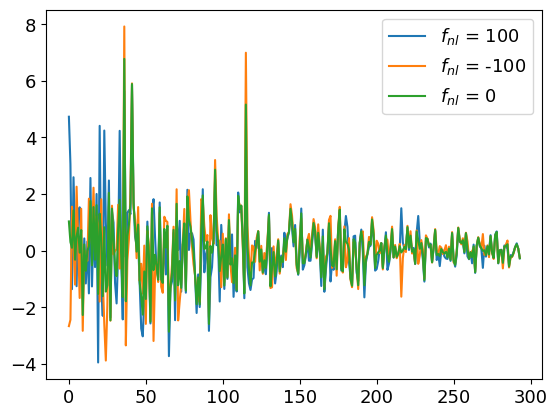

In [124]:
if run_test:
    plt.plot(BispecP.mean(0)[:,-2]*BispecP[0,:,:3].prod(1)*kF**3, label=r"$f_{nl}$ = 100")
    plt.plot(BispecM.mean(0)[:,-2]*BispecM[0,:,:3].prod(1)*kF**3, label=r"$f_{nl}$ = -100")
    plt.plot(BispecG.mean(0)[:,-2]*BispecG[0,:,:3].prod(1)*kF**3, label=r"$f_{nl}$ = 0")
    plt.legend()
    plt.show()

# Map Generation

Now we generate and save the corresponding maps.

## Generator Settings

In [119]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 2500,
    'accuracy_boost': 4,
    'tcmb': 2.7255,
}

## simulations settings
num_sim = 10**5                     # number of files to generate
num_steps = 10**5                   # Number of steps to use per file (keeps memory usage low)
num_dup_backgrounds = 5             # Number of times to use the same seed (white noise background)


fnl_range=(-1000, 1000)
BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 128                          # Size of the grid

# Number of threads to use
num_threads = -1 # for all cores

## Data Settings
base_name = f'{grid}x{num_sim//1000}k-{num_dup_backgrounds}_fnl{fnl_range[0]}-{fnl_range[1]}'
data_file = f"{base_name}"
fnl_file = f"{base_name}-fnls"

data_dir=f'data/camb/{base_name}'
clean_data_files=True

if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
elif clean_data_files:
    if os.path.isdir(data_dir):
        pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
        for file in os.listdir(data_dir):
            if pattern.match(file):
                file_path = os.path.join(data_dir, file)
                os.remove(file_path)
                print(f"Deleted file: {file_path}")
    else:
        print(f"{data_dir} exists but is not a directory!!")

# Generate extra maps such as fixed fnl maps
create_aux = True

Created directory data/camb/128x100k-5_fnl-1000-1000


In [120]:
print(f'Generating Field with {num_sim} runs of resolution {grid}, box size {BoxSize} Mpc/h')
print(f'base_name: {base_name}\ndir: {data_dir}\ndata file: {data_file}\nfnl file: {fnl_file}')
if sigma is not None: print(f'sigma: {sigma}')

Generating Field with 100000 runs of resolution 128, box size 1000.0 Mpc/h
base_name: 128x100k-5_fnl-1000-1000
dir: data/camb/128x100k-5_fnl-1000-1000
data file: 128x100k-5_fnl-1000-1000
fnl file: 128x100k-5_fnl-1000-1000-fnls
sigma: 758.0410976363985


## Generate / Load FNLs

Start by generating the fnls, loading them if possible 

In [121]:
%%time

fnl_path = os.path.join(data_dir, fnl_file + '.npy')
if os.path.exists(fnl_path):
    print(f'Loading existing fnls from {fnl_path}...')
    fnls = np.load(fnl_path)
else:
    print(f'Generating new fnls and saving to {fnl_path}...')
    fnls = np.random.uniform(fnl_range[0], fnl_range[1], num_sim).astype(np.float32)
    _save(data_dir, fnl_file + '.npy', fnls)

Generating new fnls and saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000-fnls.npy...
Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000-fnls.npy... Done!
CPU times: user 4.04 ms, sys: 1.03 ms, total: 5.07 ms
Wall time: 6.84 ms


Now we can run our simulations

In [122]:
run_simulations(data_dir, base_name, num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads) #, k_cut_high=0.25132741228718347)

Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 684 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1384 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 2284 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 3384 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 5912 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 8912 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 12312 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 24992 tasks      | elapsed:   20.7s
[Parallel(n_jobs=-1)]: Done 41792 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 60192 tasks      | elapsed:   32.6s
[Parallel(n_jobs=-1)]: Done 80192 tasks      | elapsed:   39.3s
[Parallel(n_jobs=-1)]: Done 100000 out of 100000 | elapsed:   46.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_0-100000.npy... Done!


## Generate AUX maps

In [123]:
if create_aux:
    print('Creating auxillary files use for additional analysis...')
    run_simulations(data_dir, f"{base_name}_fnl-100", num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=-100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl0"   , num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=0, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl100" , num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, force_fnl=100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_highcut", num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads, k_cut_high=1.1*kF)
    run_simulations(data_dir, f"{base_name}_lowcut" , num_sim, num_steps, num_dup_backgrounds, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads, k_cut_low=1.1*kF)

Creating auxillary files use for additional analysis...
Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 864 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 2264 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 6824 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 15624 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 26024 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done 38024 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 51624 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 66824 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 83624 tasks      | elapsed:   30.1s
[Parallel(n_jobs=-1)]: Done 99864 tasks      | elapsed:   35.3s
[Parallel(n_jobs=-1)]: Done 100000 out of 100000 | elapsed:   35.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_fnl-100_0-100000.npy... Done!
Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1152 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 3952 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 7552 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 12816 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 23216 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 35216 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 48816 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 64016 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done 80816 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 99216 tasks      | elapsed:   32.9s
[Parallel(n_jobs=-1)]: Done 100000 out of 100000 | elapsed:   33.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.4s
[Paralle

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_fnl0_0-100000.npy... Done!
Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


...

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_fnl100_0-100000.npy... Done!
Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 2192 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 8480 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 17280 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 27680 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 39680 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 53280 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 68480 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 85280 tasks      | elapsed:   30.2s
[Parallel(n_jobs=-1)]: Done 99900 tasks      | elapsed:   35.2s
[Parallel(n_jobs=-1)]: Done 100000 out of 100000 | elapsed:   35.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_highcut_0-100000.npy... Done!
Generating base field and transfers...
[ CMBMap -            init_camb() ] | INFO : Setting CAMB parameters based on cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 2500, 'accuracy_boost': 4, 'tcmb': 2.7255}
Done!


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 722 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 5096 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 12296 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 21096 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 31496 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 43496 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done 57096 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-1)]: Done 72296 tasks      | elapsed:   23.8s
[Parallel(n_jobs=-1)]: Done 89096 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 100000 out of 100000 | elapsed:   33.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 684 tasks      | elapsed:    1.4s
[Parallel(

Saving to data/camb/128x100k-5_fnl-1000-1000/128x100k-5_fnl-1000-1000_lowcut_0-100000.npy... Done!
